In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [4]:
print("Loading and cleaning data...")
df = pd.read_csv('C:\\Credit-Risk-Model\\data\\credit_train.csv')
df = df.dropna(subset=['default']).reset_index(drop=True)

df['months_last_delinq'] = df['months_last_delinq'].fillna(0)
df['employment_years'] = df['employment_years'].fillna(df['employment_years'].median())
df['savings_balance'] = df['savings_balance'].fillna(df['savings_balance'].median())

Loading and cleaning data...


In [5]:
print("Creating interaction features...")

df['loan_to_income'] = np.where(df['income'] > 0, df['loan_amount'] / df['income'], 0)
df['payment_to_income'] = np.where((df['loan_term'] > 0) & (df['income'] > 0), 
                                   (df['loan_amount'] / df['loan_term']) / df['income'] * 12, 0)
df['credit_utilization_proxy'] = np.where(df['credit_score'] > 0, 
                                          df['num_credit_lines'] / (df['credit_score'] / 100), 0)

df['dti_x_utilization'] = df['debt_to_income'] * df['credit_utilization_proxy']
df['loan_x_dti'] = df['loan_to_income'] * df['debt_to_income']
df['payment_stress'] = df['payment_to_income'] * (df['num_delinquencies'] + 1)
df['savings_to_loan'] = np.where(df['loan_amount'] > 0, df['savings_balance'] / df['loan_amount'], 0)

ratio_cols = ['loan_to_income', 'payment_to_income', 'credit_utilization_proxy', 
              'dti_x_utilization', 'loan_x_dti', 'payment_stress', 'savings_to_loan']
df[ratio_cols] = df[ratio_cols].replace([np.inf, -np.inf], 0).fillna(0)

Creating interaction features...


In [6]:
print("Computing Information Value (IV) using 10 bins...")

def compute_iv(data, feature, target, bins=10):
    try:
        temp = data[[feature, target]].copy()
        # use 10 bins
        temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')
        grouped = temp.groupby('bin', observed=True)[target].agg(['count', 'sum'])
        grouped.columns = ['Total', 'Events']
        grouped['Non_Events'] = grouped['Total'] - grouped['Events']
        
        total_events = grouped['Events'].sum()
        total_non_events = grouped['Non_Events'].sum()
        
        grouped['Dist_Events'] = grouped['Events'] / max(total_events, 1)
        grouped['Dist_Non_Events'] = grouped['Non_Events'] / max(total_non_events, 1)
        
        # smooth by 1e-9 to protect Error
        grouped['WoE'] = np.log((grouped['Dist_Events'] + 1e-9) / (grouped['Dist_Non_Events'] + 1e-9))
        grouped['IV'] = (grouped['Dist_Events'] - grouped['Dist_Non_Events']) * grouped['WoE']
        
        return grouped['IV'].sum()
    except Exception as e:
        return 0.0

features_to_test = ['credit_score', 'age', 'income', 'loan_amount', 'debt_to_income', 
                    'employment_years', 'savings_balance'] + ratio_cols

iv_results = {}
for feat in features_to_test:
    iv_results[feat] = compute_iv(df, feat, 'default', bins=10)

iv_series = pd.Series(iv_results).sort_values(ascending=False)

Computing Information Value (IV) using 10 bins...


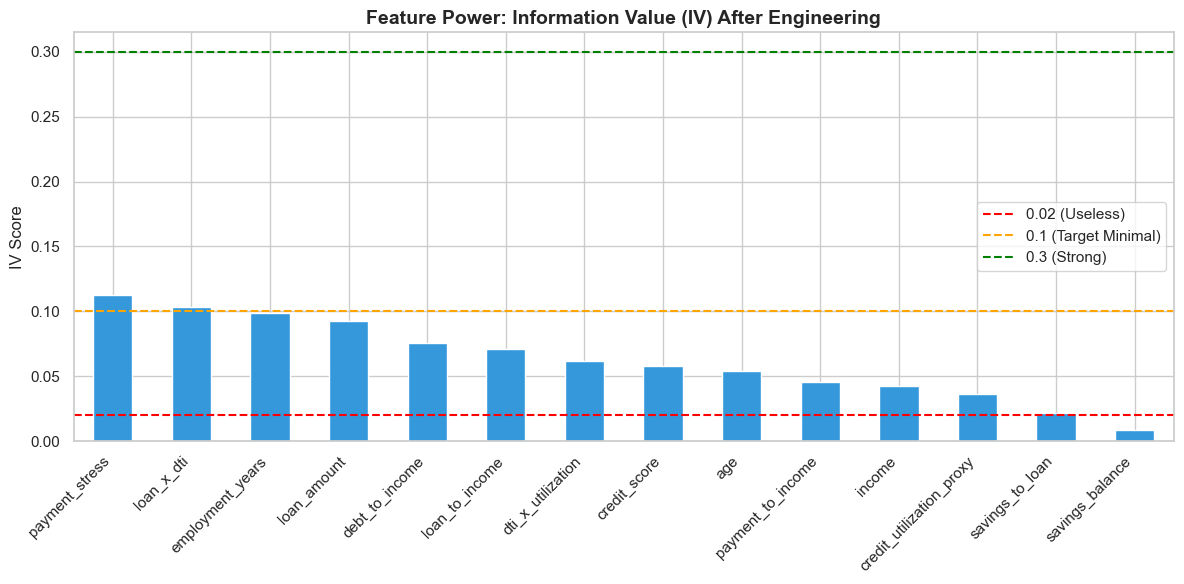

In [7]:
plt.figure(figsize=(12, 6))
ax = iv_series.plot(kind='bar', color='#3498db')

# ตีเส้น Threshold แจ้งเตือนสายตา
plt.axhline(0.02, color='red', linestyle='--', label='0.02 (Useless)')
plt.axhline(0.1, color='orange', linestyle='--', label='0.1 (Target Minimal)')
plt.axhline(0.3, color='green', linestyle='--', label='0.3 (Strong)')

plt.title('Feature Power: Information Value (IV) After Engineering', fontsize=14, fontweight='bold')
plt.ylabel('IV Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
print("\n" + "="*40)
print("TOP FEATURES (IV > 0.1)")
print("="*40)
top_features = iv_series[iv_series >= 0.1]
if len(top_features) > 0:
    print(top_features.round(4))
else:
    print("Fix again!")


TOP FEATURES (IV > 0.1)
payment_stress    0.1126
loan_x_dti        0.1036
dtype: float64
